# Lab 9: Clinical NLP - Classifying Medical Specialties from Transcriptions

**BINF 5507 - Applications III: Clinical Natural Language Processing**

In earlier labs you worked with tidy, tabular data. Real clinical data is often the opposite: roughly 80% of what lives in an electronic health record (EHR) is **unstructured free text** - progress notes, discharge summaries, radiology and pathology reports.

In this lab you will build a pipeline that turns messy clinical transcriptions into features a machine-learning model can use, and then predict the **medical specialty** a note came from. This is the same conceptual pipeline from the lecture:

> **raw text -> preprocess -> represent (features) -> classify -> evaluate**

**Learning objectives**
1. Explore and clean unstructured clinical text (callback to Lab 2).
2. Represent text numerically with **TF-IDF**.
3. Train and compare text classifiers (callback to Lab 4).
4. Evaluate honestly under **class imbalance** (accuracy vs. macro-F1).
5. See where classical NLP ends and **embeddings / LLMs** begin.

**Dataset:** `mtsamples.csv` - 4,999 transcribed medical reports across 40 specialties, scraped from mtsamples.com (CC0 public domain).

> Cells marked with `# TODO` are for you to complete. Everything else runs as-is. Look for the **Questions for Exploration** after each section.

## 0. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 200)

# The CSV lives in the same folder as this notebook
df = pd.read_csv("mtsamples.csv")
print("Raw shape:", df.shape)
df.head(3)

Raw shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with complaint of allergies.,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when she lived in Seattle but she thinks they are worse here. In the past, she has tr...","allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sprays, allergic,"
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public seating, and lifting objects off the floor. He exercises three times a week at...","bariatrics, laparoscopic gastric bypass, weight loss programs, gastric bypass, atkin's diet, weight watcher's, body weight, laparoscopic gastric, weight loss, pounds, months, weight, laparoscopic,..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC today. He is a very pleasant gentleman who is 42 years old, 344 pounds. He is 5'9"". He has a BMI of 51. He has been overweight for ten years since...","bariatrics, laparoscopic gastric bypass, heart attacks, body weight, pulmonary embolism, potential complications, sleep study, weight loss, gastric bypass, anastomosis, loss, sleep, laparoscopic, ..."


In [2]:
# The first column is just an unnamed row index - drop it
df = df.drop(columns=["Unnamed: 0"])
print("Columns:", list(df.columns))

# Look at ONE full transcription so you can see what clinical text really looks like
print(df["transcription"].iloc[0])

Columns: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal sprays.  She does have asthma but doest not require daily medication for this and does not think it is flaring up.,MEDICATIONS: , Her only medication currently is Ortho Tri-Cyclen and the Allegra.,ALLERGIES: , She has no known medicine allergies.,OBJECTIVE:,Vitals:  Weight was 130 pounds and blood pressure 124/78.,HEENT:  Her throat was mildly erythematous without exudate.  Nasal mucosa was erythematous and sw

**Column guide**
- `description` - a one-line summary of the report
- `medical_specialty` - the label we will try to predict
- `sample_name` - short title of the report
- `transcription` - the full note text (our main input)
- `keywords` - manually assigned keywords (a possible source of leakage - see Questions)

#### Questions for Exploration
1. Skim the transcription printed above. What structure do you notice (section headers, punctuation, abbreviations)? Why might this be harder to model than the tabular data from Lab 4?
2. The `keywords` column often literally contains the specialty name. If we trained on `keywords`, why would our accuracy be misleadingly high? (This is a classic **data leakage** trap.)

## 1. Exploring the Text (EDA)

In [3]:
# Specialty labels have leading/trailing whitespace - strip it first
df["medical_specialty"] = df["medical_specialty"].str.strip()

print("Number of specialties:", df["medical_specialty"].nunique())
counts = df["medical_specialty"].value_counts()
print(counts.head(15))

Number of specialties: 40
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Name: count, dtype: int64


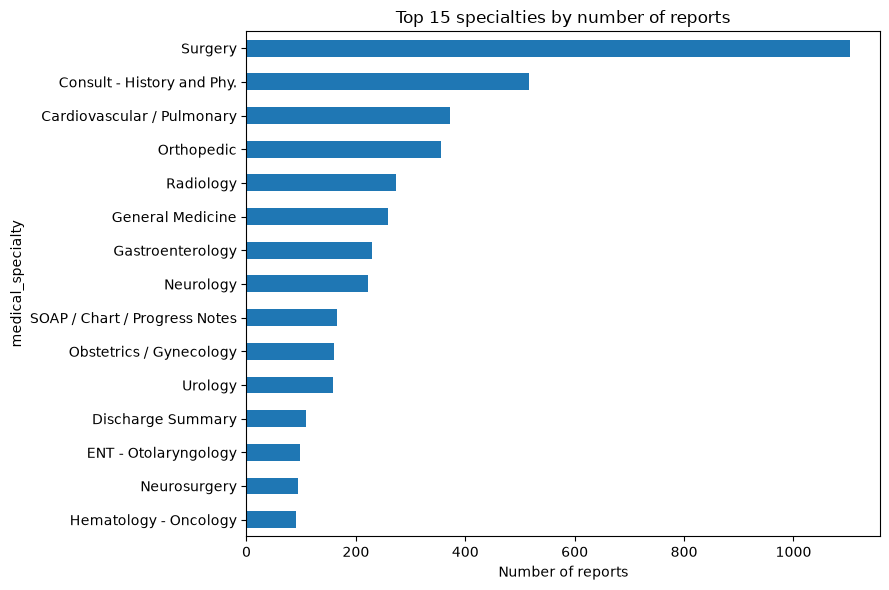

In [4]:
# Visualise the class distribution
plt.figure(figsize=(9, 6))
counts.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 specialties by number of reports")
plt.xlabel("Number of reports")
plt.tight_layout()
plt.show()

In [5]:
# How much text is in each note? (word count distribution)
df["n_words"] = df["transcription"].fillna("").str.split().apply(len)
df["n_words"].describe()

count    4999.000000
mean      462.376275
std       317.585206
min         0.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: n_words, dtype: float64

In [6]:
# Some transcriptions are missing - we cannot model an empty note
print("Missing transcriptions:", df["transcription"].isna().sum())
df = df.dropna(subset=["transcription"]).reset_index(drop=True)
print("Rows after dropping missing:", len(df))

Missing transcriptions: 33
Rows after dropping missing: 4966


#### Questions for Exploration
1. The class distribution is heavily **imbalanced** (`Surgery` has ~1,100 reports; several specialties have fewer than 20). If a model just always guessed "Surgery", roughly what accuracy would it get? Why does that make plain accuracy a poor metric here?
2. Look at the top categories. Which of these are true clinical *specialties* and which are really *document types* (e.g., `Consult - History and Phy.`, `SOAP / Chart / Progress Notes`)? We will deal with this in Section 3.

## 2. Text Preprocessing (callback to Lab 2)

Clinical transcriptions in this dataset use commas as inline section delimiters (e.g. `,MEDICATIONS:,`) and are full of punctuation and numbers. Before we can build features we normalise the text: lowercase it, remove the comma-delimiters and non-letter characters, and collapse extra whitespace.

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r",", " ", text)          # inline comma delimiters -> spaces
    text = re.sub(r"[^a-z\s]", " ", text)   # drop digits and punctuation
    text = re.sub(r"\s+", " ", text).strip() # collapse whitespace
    return text

# Compare a raw vs. cleaned snippet
raw = df["transcription"].iloc[0]
print("RAW:\n", raw[:300])
print("\nCLEANED:\n", clean_text(raw)[:300])

RAW:
 SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has us

CLEANED:
 subjective this year old white female presents with complaint of allergies she used to have allergies when she lived in seattle but she thinks they are worse here in the past she has tried claritin and zyrtec both worked for short time but then seemed to lose effectiveness she has used allegra also 


In [8]:
# Apply cleaning to every note (creates a new 'clean' column)
df["clean"] = df["transcription"].apply(clean_text)
df[["medical_specialty", "clean"]].head(3)

,medical_specialty,clean
0,Allergy / Immunology,subjective this year old white female presents with complaint of allergies she used to have allergies when she lived in seattle but she thinks they are worse here in the past she has tried clariti...
1,Bariatrics,past medical history he has difficulty climbing stairs difficulty with airline seats tying shoes used to public seating and lifting objects off the floor he exercises three times a week at home an...
2,Bariatrics,history of present illness i have seen abc today he is a very pleasant gentleman who is years old pounds he is he has a bmi of he has been overweight for ten years since the age of at his highest ...


#### Questions for Exploration
1. Our cleaner deletes **all digits**. For predicting specialty that is probably fine - but name a clinical NLP task where throwing away numbers would be a serious mistake.
2. Generic English stop-word lists remove words like "no" and "not". In clinical text, why is deleting negation words potentially dangerous? (Think: "no evidence of malignancy".)

## 3. Scoping the Problem

Trying to classify all 40 categories at once is hard and noisy: several categories are document *types* rather than specialties, and the smallest classes have too few examples to learn from. We will focus on **10 genuinely distinct clinical specialties**. This keeps the problem tractable and the results interpretable - a deliberate modelling choice, not cheating.

In [9]:
keep = [
    "Cardiovascular / Pulmonary", "Orthopedic", "Radiology",
    "Gastroenterology", "Neurology", "Obstetrics / Gynecology",
    "Urology", "Nephrology", "ENT - Otolaryngology", "Ophthalmology",
]
data = df[df["medical_specialty"].isin(keep)].copy().reset_index(drop=True)
print("Scoped rows:", len(data), "| classes:", data["medical_specialty"].nunique())
data["medical_specialty"].value_counts()

Scoped rows: 2017 | classes: 10


medical_specialty
Cardiovascular / Pulmonary    371
Orthopedic                    355
Radiology                     273
Gastroenterology              224
Neurology                     223
Urology                       156
Obstetrics / Gynecology       155
ENT - Otolaryngology           96
Ophthalmology                  83
Nephrology                     81
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

# Stratified split so every specialty appears in both train and test in the same proportion
X_train, X_test, y_train, y_test = train_test_split(
    data["clean"], data["medical_specialty"],
    test_size=0.2, stratify=data["medical_specialty"], random_state=42,
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 1613 | Test: 404


#### Questions for Exploration
1. We passed `stratify=data["medical_specialty"]`. What could go wrong on this imbalanced dataset if we did a plain random split instead?
2. We reduced 40 classes to 10. What kind of note would this model have *no chance* of classifying correctly now, and is that an acceptable trade-off for a teaching example?

## 4. Feature Representation: TF-IDF

A model cannot read text - we must turn each note into a vector of numbers. **TF-IDF** (Term Frequency-Inverse Document Frequency) weights each word by how often it appears in a note, down-weighted by how common it is across *all* notes. Distinctive clinical terms (e.g. "coronary", "fracture") get high weights; ubiquitous words get low weights.

**TODO:** create a `TfidfVectorizer`, fit it on the training text, and transform both splits.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Keep the feature space manageable while retaining informative phrases.
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
)

# Learn the vocabulary and IDF weights only from the training split.
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Feature matrix shape (train):", X_train_tfidf.shape)

Feature matrix shape (train): (1613, 5000)


In [12]:
# Peek at the highest-weighted terms overall (sanity check)
import numpy as np
feature_names = np.array(vectorizer.get_feature_names_out())
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top = feature_names[mean_tfidf.argsort()[::-1][:20]]
print("Top 20 terms by mean TF-IDF:\n", list(top))

Top 20 terms by mean TF-IDF:
 ['patient', 'right', 'left', 'normal', 'procedure', 'history', 'placed', 'pain', 'mg', 'using', 'artery', 'diagnosis', 'performed', 'noted', 'exam', 'time', 'removed', 'anesthesia', 'used', 'incision']


#### Questions for Exploration
1. What is the shape of your feature matrix (rows x columns)? Compare the number of features to the number of training notes - this **high-dimensional, few-sample** situation is exactly the "curse of dimensionality" from the imaging lecture.
2. Re-run with `ngram_range=(1, 1)` (single words only) vs. `(1, 2)`. How does the vocabulary size change, and why might bigrams like "chest pain" help?

## 5. Classification (callback to Lab 4)

Now we train classifiers on the TF-IDF features. As in Lab 4 we compare several models. Because the classes are imbalanced, we pass `class_weight="balanced"` where the model supports it (Naive Bayes does not).

**TODO:** complete the training loop.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced"),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro")
    results[name] = {"model": model, "preds": preds, "acc": acc, "macro_f1": macro_f1}
    print(f"{name:26s}  accuracy={acc:.3f}  macro-F1={macro_f1:.3f}")

Logistic Regression         accuracy=0.735  macro-F1=0.753
Multinomial Naive Bayes     accuracy=0.696  macro-F1=0.639
Linear SVM                  accuracy=0.666  macro-F1=0.694


#### Questions for Exploration
1. Which model performs best on **macro-F1**? Is it the same model that wins on accuracy? Why can these disagree?
2. Naive Bayes and linear models are strong baselines for text. Why do simple linear models tend to work well on high-dimensional, sparse TF-IDF features?

## 6. Evaluation

Accuracy alone hides *where* a model fails. We look at the per-class report and a confusion matrix to see which specialties get mixed up - and whether those confusions are clinically sensible.

In [14]:
from sklearn.metrics import classification_report

# Pick the best model by macro-F1
best_name = max(results, key=lambda k: results[k]["macro_f1"])
best = results[best_name]
print(f"Best model: {best_name}\n")

print(classification_report(y_test, best["preds"]))

Best model: Logistic Regression

                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.77      0.78      0.78        74
      ENT - Otolaryngology       0.84      0.84      0.84        19
          Gastroenterology       0.86      0.82      0.84        45
                Nephrology       0.56      0.62      0.59        16
                 Neurology       0.57      0.73      0.64        45
   Obstetrics / Gynecology       0.80      0.90      0.85        31
             Ophthalmology       1.00      1.00      1.00        17
                Orthopedic       0.89      0.82      0.85        71
                 Radiology       0.30      0.24      0.27        55
                   Urology       0.87      0.87      0.87        31

                  accuracy                           0.74       404
                 macro avg       0.75      0.76      0.75       404
              weighted avg       0.73      0.74      0.73       404



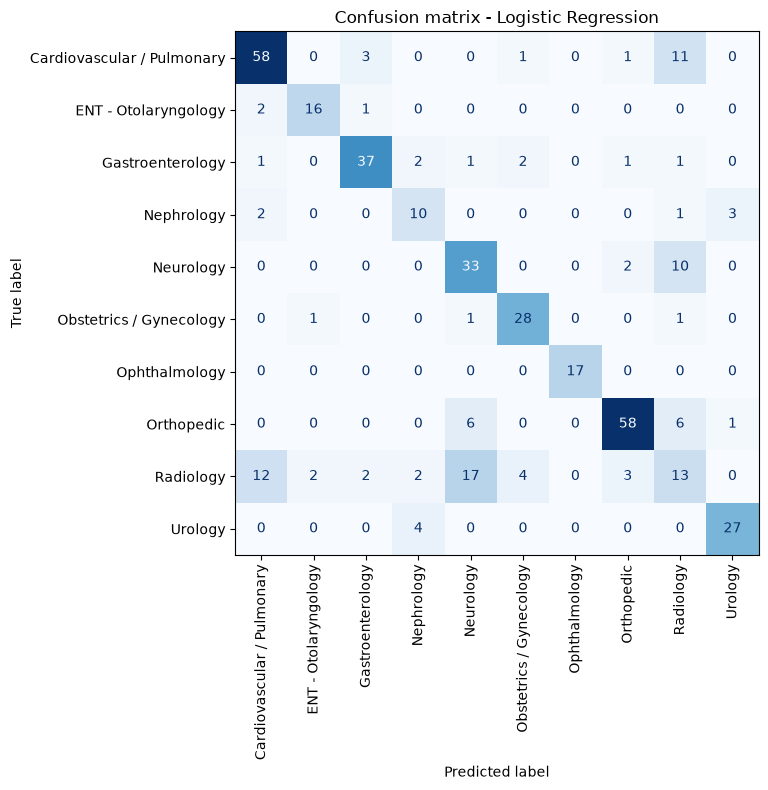

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, best["preds"],
    xticks_rotation="vertical", cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title(f"Confusion matrix - {best_name}")
plt.tight_layout()
plt.show()

#### Questions for Exploration
1. Find the two specialties that are most often confused with each other. Does that confusion make clinical sense (e.g. overlapping vocabulary)?
2. Which specialty has the lowest recall? Look back at Section 3 - is its training-set size part of the story?
3. `macro-F1` averages F1 across classes equally; `weighted-F1` weights by class size. For a clinical triage tool, which would you report to a stakeholder, and why?

## 7. Extensions

The core pipeline above is deliberately "classical" (TF-IDF + linear model). These optional extensions push toward modern NLP. Some require extra installs and downloads - run only what your environment allows.

### 7a. Handling Imbalance Explicitly

We already used `class_weight="balanced"`. Here you can quantify its effect: train a Logistic Regression **with** and **without** balancing and compare macro-F1. **TODO** below.

In [16]:
plain    = LogisticRegression(max_iter=1000)                          # no balancing
balanced = LogisticRegression(max_iter=1000, class_weight="balanced")  # with balancing

for label, m in [("plain", plain), ("balanced", balanced)]:
    m.fit(X_train_tfidf, y_train)
    p = m.predict(X_test_tfidf)
    # TODO: print accuracy and macro-F1 for each and compare
    print(f"{label:9s}  acc={accuracy_score(y_test, p):.3f}  macro-F1={f1_score(y_test, p, average='macro'):.3f}")

plain      acc=0.713  macro-F1=0.729
balanced   acc=0.735  macro-F1=0.753


### 7b. Learned Features: Sentence Embeddings

TF-IDF treats words as independent tokens and ignores meaning ("MI" vs. "heart attack" are unrelated to it). **Embeddings** map text into a dense semantic space. This is the "handcrafted vs. learned features" contrast from the lecture.

> Requires: `pip install sentence-transformers` (downloads a ~90 MB model on first run). If you cannot install it, read the code and skip execution.

In [17]:
# Optional - comment back in if sentence-transformers is installed.
#
# from sentence_transformers import SentenceTransformer
# from sklearn.linear_model import LogisticRegression
#
# encoder = SentenceTransformer("all-MiniLM-L6-v2")
# # Embed the raw (uncleaned) transcriptions - the model handles casing/punctuation itself.
# emb_train = encoder.encode(list(X_train), show_progress_bar=True)
# emb_test  = encoder.encode(list(X_test),  show_progress_bar=True)
#
# clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(emb_train, y_train)
# emb_preds = clf.predict(emb_test)
# print("Embedding + LogReg  macro-F1 =", f1_score(y_test, emb_preds, average="macro"))
#
# TODO: does the embedding model beat TF-IDF here? On a dataset this small, it often does NOT.
#       Why might a huge pretrained model not help when you only have ~1,600 training notes?
print("See commented code - requires sentence-transformers.")

See commented code - requires sentence-transformers.


### 7c. Named Entity Recognition (NER): Pulling Structure Out of Text

Classification gives one label per note. **NER** extracts specific entities (drugs, problems, anatomy) - turning free text into structured fields, the real goal of clinical NLP.

> Requires: `pip install scispacy` and a model, e.g.
> `pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz`
> If unavailable, the regex fallback below still runs and illustrates the idea.

In [18]:
# --- Option A: scispaCy (biomedical NER) - requires install ---
# import spacy
# nlp = spacy.load("en_ner_bc5cdr_md")   # detects CHEMICAL and DISEASE entities
# doc = nlp(df["transcription"].iloc[0])
# for ent in doc.ents:
#     print(f"{ent.text:30s} -> {ent.label_}")

# --- Option B: no-install regex fallback (crude, illustrative only) ---
sample = df["transcription"].iloc[0]
# naive 'vital-sign / measurement' grabber
measurements = re.findall(r"\d+\.?\d*\s?(?:mg|mm|cm|pounds|/\d+)", sample.lower())
print("Regex-extracted measurements:", measurements)

Regex-extracted measurements: ['130 pounds', '124/78']


**TODO:** compare the two approaches. Why is a trained NER model (Option A) far more robust than regex (Option B) for extracting drug or disease mentions? Give one example where regex would clearly fail.

### 7d. LLMs for Classification (Discussion / Pseudo-code)

A modern alternative is to *prompt* a large language model - no training required. This is **discussion-only** (running it needs API access and would send data to a third party - a real privacy concern for PHI).

Consider the prompt below and answer the questions - do **not** run it.

```
You are a medical coding assistant. Read the clinical note and respond with
exactly one specialty from this list: [Cardiovascular / Pulmonary, Orthopedic,
Radiology, Gastroenterology, Neurology, Obstetrics / Gynecology, Urology,
Nephrology, ENT - Otolaryngology, Ophthalmology].

Note:
"""{transcription}"""

Specialty:
```

#### Questions for Exploration
1. A zero-shot LLM needs **no labelled training data**. What are two advantages over our TF-IDF model, and two serious risks in a clinical setting (think privacy, hallucination, cost, reproducibility)?
2. How would you *evaluate* the LLM's answers against our test set to compare it fairly with the classifier? (What metric, what ground truth?)
3. When would you still prefer the simple, transparent TF-IDF + Logistic Regression model over an LLM?

## Wrap-up

You built an end-to-end clinical-text pipeline: **clean -> TF-IDF -> classify -> evaluate**, dealt with real class imbalance, and looked past classical NLP toward embeddings, NER, and LLMs.

**Key takeaways**
- Unstructured clinical text needs deliberate preprocessing before any model can use it.
- TF-IDF + a linear classifier is a strong, transparent baseline for clinical text.
- On imbalanced clinical data, **macro-F1 and the confusion matrix** tell you far more than accuracy.
- Bigger models (embeddings, LLMs) are not automatically better on small datasets - and they bring privacy, cost, and reproducibility trade-offs, which we revisit in the Bias & Fairness lecture.